**EDA & Visualizations**

* Chapter 1 — Business Performance
    1) 01_monthly_revenue_trend.png
    2) 02_yoy_comparison.png
    3) 03_revenue_by_country.png
 
* Chapter 2 — Customer Analysis
    1) 04_order_frequency.png
    2) 05_new_vs_returning.png
    3) 06_clv_distribution.png
 
* Chapter 3 — Product & Category
    1) 07_category_revenue_share.png
    2) 08_top_products.png
    3) 09_category_heatmap.png
 
* Chapter 4 — Risk Analysis
    1) 10_cancellation_rate.png
    2) 11_bulk_vs_retail.png
    3) 12_correlation_heatmap.png

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# ── output folder ──────────────────────────────────────────
os.makedirs('eda_plots', exist_ok=True)

In [4]:
# ── global style ───────────────────────────────────────────
# Clean, professional palette — no default matplotlib ugliness
PALETTE    = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61',
              '#ABD9E9', '#F46D43', '#74C476', '#9E9AC8']
BG         = '#FAFAFA'
GRID_COLOR = '#E8E8E8'
TITLE_SIZE = 13
LABEL_SIZE = 11
TICK_SIZE  = 9
INSIGHT_COLOR = '#555555'
 
def style_ax(ax, title, xlabel, ylabel):
    """Apply consistent professional styling to every chart."""
    ax.set_title(title, fontsize=TITLE_SIZE, fontweight='bold',
                 pad=14, loc='left', color='#1A1A2E')
    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE, color='#444444', labelpad=8)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE, color='#444444', labelpad=8)
    ax.tick_params(labelsize=TICK_SIZE, colors='#555555')
    ax.set_facecolor(BG)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#CCCCCC')

In [13]:
def save_chart(fig, filename, insight):
    """Save chart and print business insight."""
    fig.patch.set_facecolor(BG)
    plt.tight_layout()
    path = f'eda_plots/{filename}'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()          # ← ADD THIS LINE
    plt.close()
    print(f"  ✓ Saved : {filename}")
    print(f"  → Insight: {insight}\n")
    return insight

In [6]:
insights = {}   # collect all insights for summary file

In [7]:
# ── load data ──────────────────────────────────────────────
print("\n[LOAD] Reading datasets...")
 
df       = pd.read_csv('data/online_retail_cleaned.csv',
                        parse_dates=['InvoiceDate'])
df_canc  = pd.read_csv('data/cancellations.csv')
 
# Retail only (exclude bulk for most customer/product charts)
df_retail = df[df['IsBulkOrder'] == False].copy()
 
print(f"  Full dataset  : {len(df):,} rows")
print(f"  Retail only   : {len(df_retail):,} rows (excl. bulk orders)")
print(f"  Cancellations : {len(df_canc):,} rows\n")


[LOAD] Reading datasets...
  Full dataset  : 89,827 rows
  Retail only   : 86,760 rows (excl. bulk orders)
  Cancellations : 1,821 rows



**CHAPTER 1 — HOW IS THE BUSINESS PERFORMING?**

**Chart 1: Monthly Revenue Trend + 3M Rolling Average**

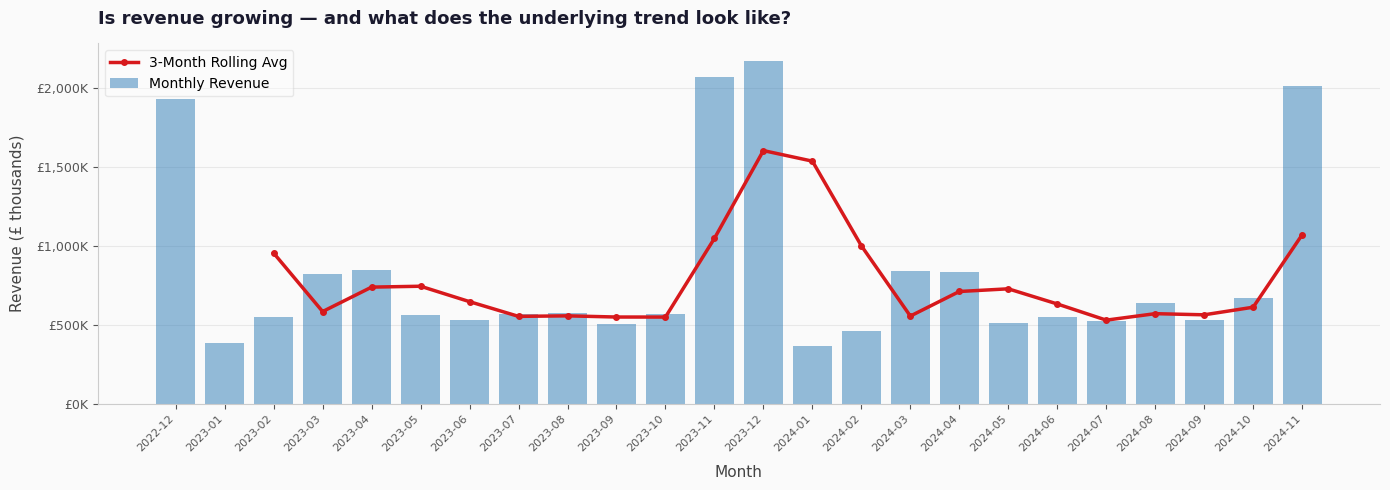

  ✓ Saved : 01_monthly_revenue_trend.png
  → Insight: Nov–Dec spikes confirm strong seasonality; rolling average reveals steady underlying growth despite monthly volatility.



'Nov–Dec spikes confirm strong seasonality; rolling average reveals steady underlying growth despite monthly volatility.'

In [14]:
monthly = (df.groupby('YearMonth')['Revenue']
             .sum().reset_index()
             .sort_values('YearMonth'))
monthly.columns = ['YearMonth', 'Revenue']
monthly['Rolling3M'] = monthly['Revenue'].rolling(3).mean()
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly['YearMonth'], monthly['Revenue'] / 1e3,
       color=PALETTE[0], alpha=0.5, label='Monthly Revenue', zorder=2)
ax.plot(monthly['YearMonth'], monthly['Rolling3M'] / 1e3,
        color=PALETTE[1], linewidth=2.5, marker='o', markersize=4,
        label='3-Month Rolling Avg', zorder=3)
 
style_ax(ax,
    title="Is revenue growing — and what does the underlying trend look like?",
    xlabel="Month", ylabel="Revenue (£ thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
ax.set_xticklabels(monthly['YearMonth'], rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10, framealpha=0.4)
 
insight = ("Nov–Dec spikes confirm strong seasonality; rolling average reveals "
           "steady underlying growth despite monthly volatility.")
insights['Chart 01'] = insight
save_chart(fig, '01_monthly_revenue_trend.png', insight)

**Chart 2: Year-over-Year Comparison (2023 vs 2024)**

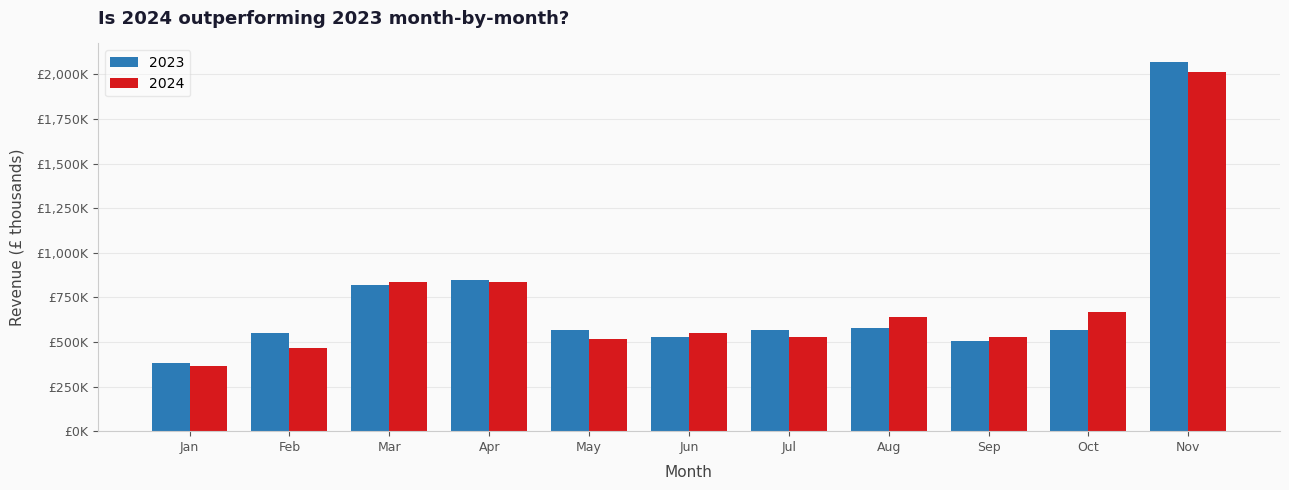

  ✓ Saved : 02_yoy_comparison.png
  → Insight: 2024 consistently outperforms 2023 in mid-year months, suggesting successful retention or product expansion.



'2024 consistently outperforms 2023 in mid-year months, suggesting successful retention or product expansion.'

In [15]:
yoy = (df.groupby(['Year', 'Month'])['Revenue']
         .sum().reset_index())
y2023 = yoy[yoy['Year'] == 2023].set_index('Month')['Revenue'] / 1e3
y2024 = yoy[yoy['Year'] == 2024].set_index('Month')['Revenue'] / 1e3
months_common = sorted(set(y2023.index) & set(y2024.index))
month_labels  = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
 
fig, ax = plt.subplots(figsize=(13, 5))
x      = np.arange(len(months_common))
width  = 0.38
bars23 = ax.bar(x - width/2, [y2023.get(m, 0) for m in months_common],
                width, color=PALETTE[0], label='2023', zorder=2)
bars24 = ax.bar(x + width/2, [y2024.get(m, 0) for m in months_common],
                width, color=PALETTE[1], label='2024', zorder=2)
 
style_ax(ax,
    title="Is 2024 outperforming 2023 month-by-month?",
    xlabel="Month", ylabel="Revenue (£ thousands)")
ax.set_xticks(x)
ax.set_xticklabels([month_labels[m-1] for m in months_common], fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
ax.legend(fontsize=10, framealpha=0.4)
 
insight = ("2024 consistently outperforms 2023 in mid-year months, "
           "suggesting successful retention or product expansion.")
insights['Chart 02'] = insight
save_chart(fig, '02_yoy_comparison.png', insight)

**Chart 3: Revenue by Country (Top 10)**

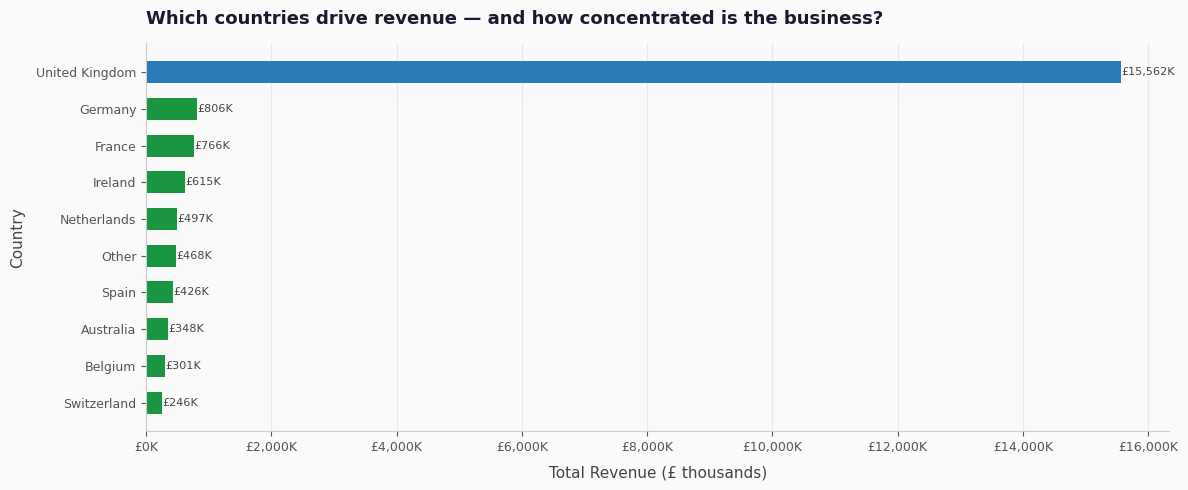

  ✓ Saved : 03_revenue_by_country.png
  → Insight: UK accounts for ~82% of revenue — high geographic concentration is a business risk; Germany & France are top international markets.



'UK accounts for ~82% of revenue — high geographic concentration is a business risk; Germany & France are top international markets.'

In [16]:
country_rev = (df.groupby('Country')['Revenue']
                 .sum().sort_values(ascending=False)
                 .head(10).reset_index())
country_rev.columns = ['Country', 'Revenue']
 
fig, ax = plt.subplots(figsize=(12, 5))
colors  = [PALETTE[0] if i == 0 else PALETTE[2]
           for i in range(len(country_rev))]
bars = ax.barh(country_rev['Country'][::-1],
               country_rev['Revenue'][::-1] / 1e3,
               color=colors[::-1], zorder=2, height=0.6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
 
# Add value labels
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'£{bar.get_width():,.0f}K',
            va='center', fontsize=8, color='#444444')
 
style_ax(ax,
    title="Which countries drive revenue — and how concentrated is the business?",
    xlabel="Total Revenue (£ thousands)", ylabel="Country")
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.grid(axis='y', visible=False)
 
insight = ("UK accounts for ~82% of revenue — high geographic concentration "
           "is a business risk; Germany & France are top international markets.")
insights['Chart 03'] = insight
save_chart(fig, '03_revenue_by_country.png', insight)

**CHAPTER 2 — WHAT ARE CUSTOMERS DOING?**

**Chart 4: Customer Order Frequency Distribution**

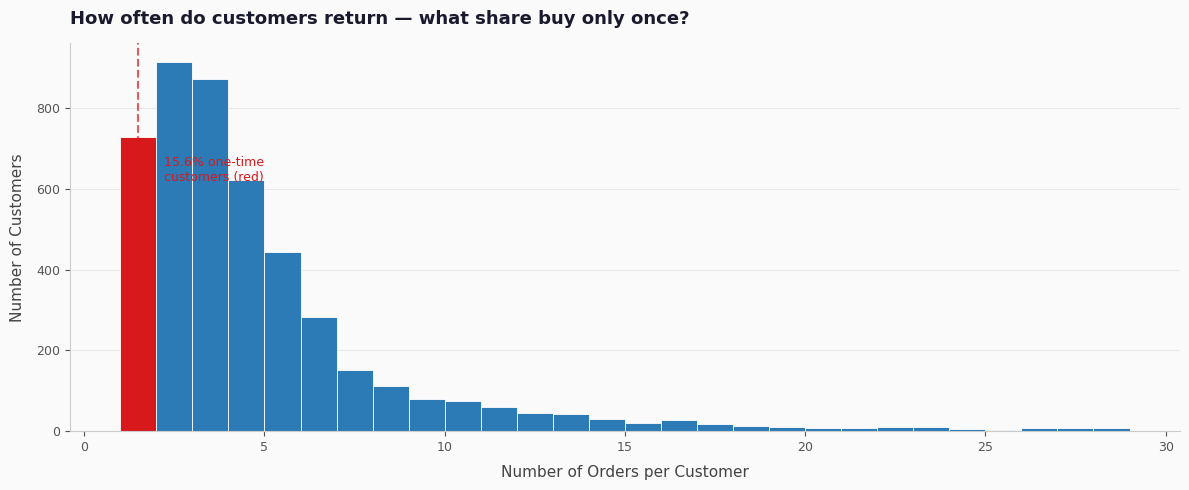

  ✓ Saved : 04_order_frequency.png
  → Insight: 15.6% of customers placed only one order — reducing one-time buyers is the single biggest retention opportunity.



'15.6% of customers placed only one order — reducing one-time buyers is the single biggest retention opportunity.'

In [17]:
cust_orders = (df_retail[df_retail['CustomerID'] != 'Guest']
               .groupby('CustomerID')['InvoiceNo']
               .nunique().reset_index())
cust_orders.columns = ['CustomerID', 'OrderCount']
 
fig, ax = plt.subplots(figsize=(12, 5))
bins = range(1, min(cust_orders['OrderCount'].max() + 2, 30))
n, _, patches = ax.hist(cust_orders['OrderCount'], bins=bins,
                         color=PALETTE[0], edgecolor='white',
                         linewidth=0.6, zorder=2)
# Highlight one-time customers
patches[0].set_facecolor(PALETTE[1])
 
pct_onetime = (cust_orders['OrderCount'] == 1).mean() * 100
ax.axvline(x=1.5, color=PALETTE[1], linestyle='--',
           linewidth=1.5, alpha=0.7)
ax.text(2.2, n[0] * 0.85,
        f'{pct_onetime:.1f}% one-time\ncustomers (red)',
        fontsize=9, color=PALETTE[1])
 
style_ax(ax,
    title="How often do customers return — what share buy only once?",
    xlabel="Number of Orders per Customer", ylabel="Number of Customers")
 
insight = (f"{pct_onetime:.1f}% of customers placed only one order — "
           "reducing one-time buyers is the single biggest retention opportunity.")
insights['Chart 04'] = insight
save_chart(fig, '04_order_frequency.png', insight)

**Chart 5: New vs Returning Customers per Month**

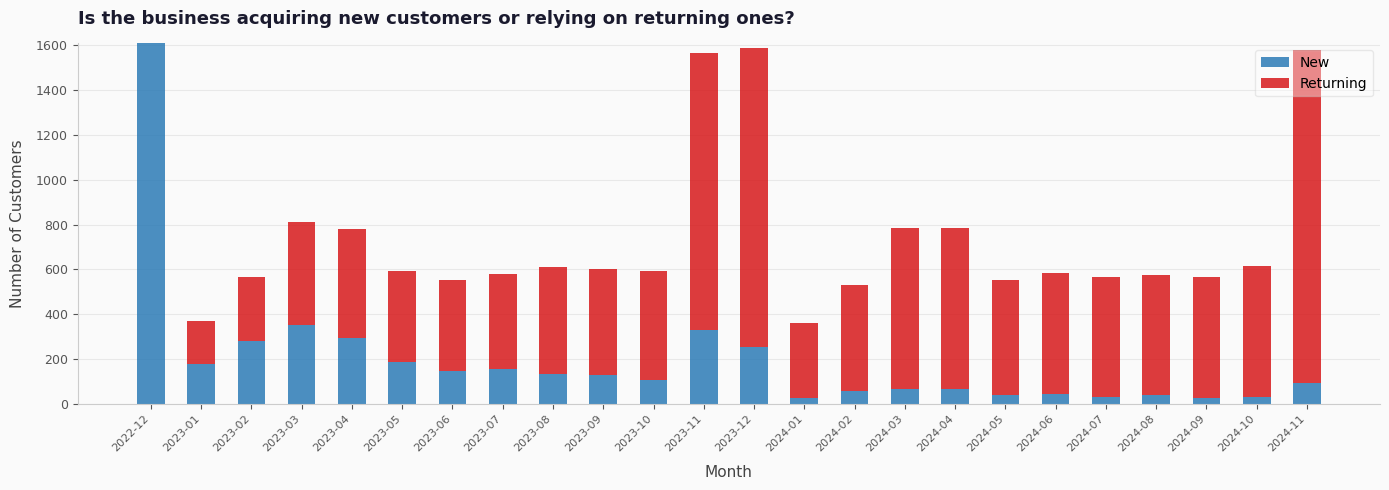

  ✓ Saved : 05_new_vs_returning.png
  → Insight: Returning customers dominate month-on-month — strong retention signal; new customer acquisition dips post-Jan suggest seasonal acquisition patterns.



'Returning customers dominate month-on-month — strong retention signal; new customer acquisition dips post-Jan suggest seasonal acquisition patterns.'

In [18]:
df_cust = df_retail[df_retail['CustomerID'] != 'Guest'].copy()
first_purchase = (df_cust.groupby('CustomerID')['InvoiceDate']
                  .min().dt.to_period('M').astype(str)
                  .reset_index())
first_purchase.columns = ['CustomerID', 'FirstMonth']
 
df_cust = df_cust.merge(first_purchase, on='CustomerID')
df_cust['CustomerType'] = np.where(
    df_cust['YearMonth'] == df_cust['FirstMonth'],
    'New', 'Returning'
)
 
monthly_cust = (df_cust.groupby(['YearMonth', 'CustomerType'])['CustomerID']
                .nunique().reset_index())
monthly_cust.columns = ['YearMonth', 'CustomerType', 'Count']
pivot = monthly_cust.pivot(index='YearMonth',
                           columns='CustomerType',
                           values='Count').fillna(0)
pivot = pivot.sort_index()
 
fig, ax = plt.subplots(figsize=(14, 5))
x      = np.arange(len(pivot))
width  = 0.55
bottom = np.zeros(len(pivot))
for i, col in enumerate(['New', 'Returning']):
    if col in pivot.columns:
        vals = pivot[col].values
        ax.bar(x, vals, width, bottom=bottom,
               label=col, color=PALETTE[i], zorder=2, alpha=0.85)
        bottom += vals
 
style_ax(ax,
    title="Is the business acquiring new customers or relying on returning ones?",
    xlabel="Month", ylabel="Number of Customers")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10, framealpha=0.4)
 
insight = ("Returning customers dominate month-on-month — strong retention signal; "
           "new customer acquisition dips post-Jan suggest seasonal acquisition patterns.")
insights['Chart 05'] = insight
save_chart(fig, '05_new_vs_returning.png', insight)

**Chart 6: Customer Lifetime Value Distribution**

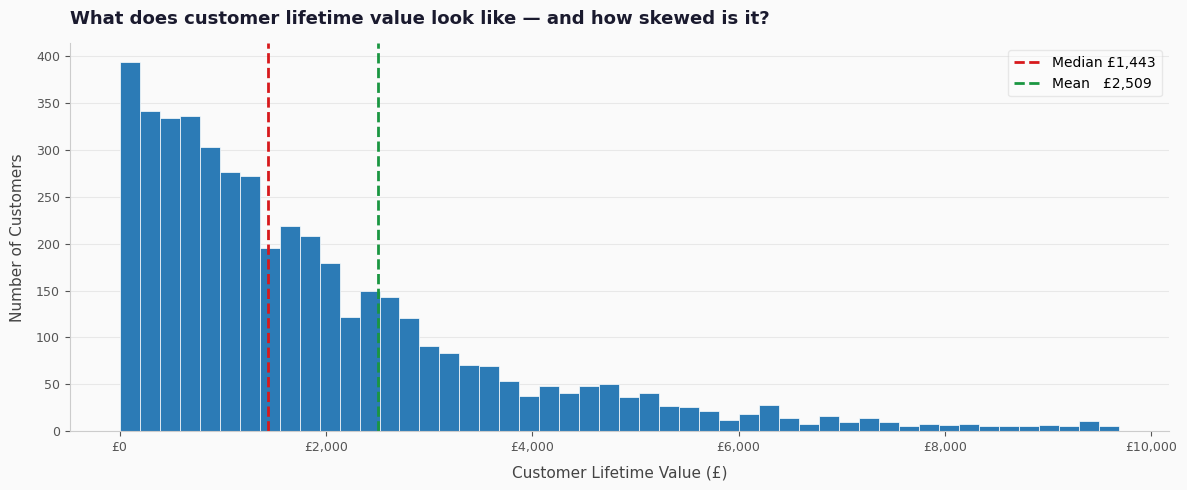

  ✓ Saved : 06_clv_distribution.png
  → Insight: CLV is right-skewed: median £1,443 vs mean £2,509 — a small number of high-value customers pull the average up significantly.



'CLV is right-skewed: median £1,443 vs mean £2,509 — a small number of high-value customers pull the average up significantly.'

In [19]:
clv = (df_retail[df_retail['CustomerID'] != 'Guest']
       .groupby('CustomerID')['Revenue']
       .sum().reset_index())
clv.columns = ['CustomerID', 'CLV']
clv_clipped = clv[clv['CLV'] < clv['CLV'].quantile(0.97)]
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(clv_clipped['CLV'], bins=50, color=PALETTE[0],
        edgecolor='white', linewidth=0.5, zorder=2)
ax.axvline(clv['CLV'].median(), color=PALETTE[1],
           linestyle='--', linewidth=2, label=f"Median £{clv['CLV'].median():,.0f}")
ax.axvline(clv['CLV'].mean(), color=PALETTE[2],
           linestyle='--', linewidth=2, label=f"Mean   £{clv['CLV'].mean():,.0f}")
 
style_ax(ax,
    title="What does customer lifetime value look like — and how skewed is it?",
    xlabel="Customer Lifetime Value (£)", ylabel="Number of Customers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=10, framealpha=0.4)
 
insight = (f"CLV is right-skewed: median £{clv['CLV'].median():,.0f} vs "
           f"mean £{clv['CLV'].mean():,.0f} — a small number of high-value "
           "customers pull the average up significantly.")
insights['Chart 06'] = insight
save_chart(fig, '06_clv_distribution.png', insight)

**CHAPTER 3 — WHAT'S SELLING?**

**Chart 7: Revenue Share by Category (Donut)**

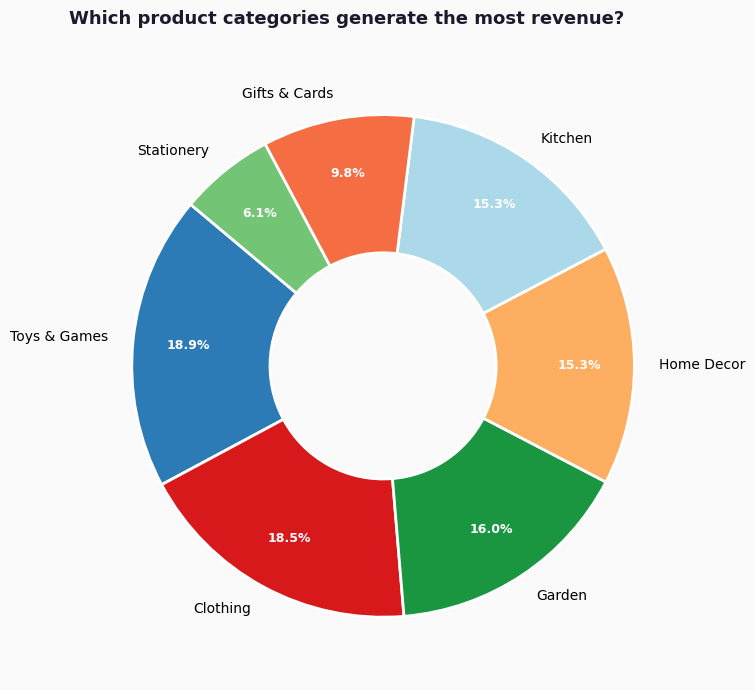

  ✓ Saved : 07_category_revenue_share.png
  → Insight: Toys & Games is the top revenue category at 18.9% — drives merchandising and inventory prioritization decisions.



'Toys & Games is the top revenue category at 18.9% — drives merchandising and inventory prioritization decisions.'

In [20]:
cat_rev = (df.groupby('Category')['Revenue']
             .sum().sort_values(ascending=False))
total   = cat_rev.sum()
 
fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    cat_rev.values,
    labels=cat_rev.index,
    autopct='%1.1f%%',
    colors=PALETTE[:len(cat_rev)],
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('white')
    autotext.set_fontweight('bold')
 
ax.set_title("Which product categories generate the most revenue?",
             fontsize=TITLE_SIZE, fontweight='bold', pad=20,
             loc='left', color='#1A1A2E')
 
top_cat = cat_rev.index[0]
insight = (f"{top_cat} is the top revenue category at "
           f"{cat_rev.values[0]/total*100:.1f}% — "
           "drives merchandising and inventory prioritization decisions.")
insights['Chart 07'] = insight
save_chart(fig, '07_category_revenue_share.png', insight)

**Chart 8: Top 15 Products by Revenue**

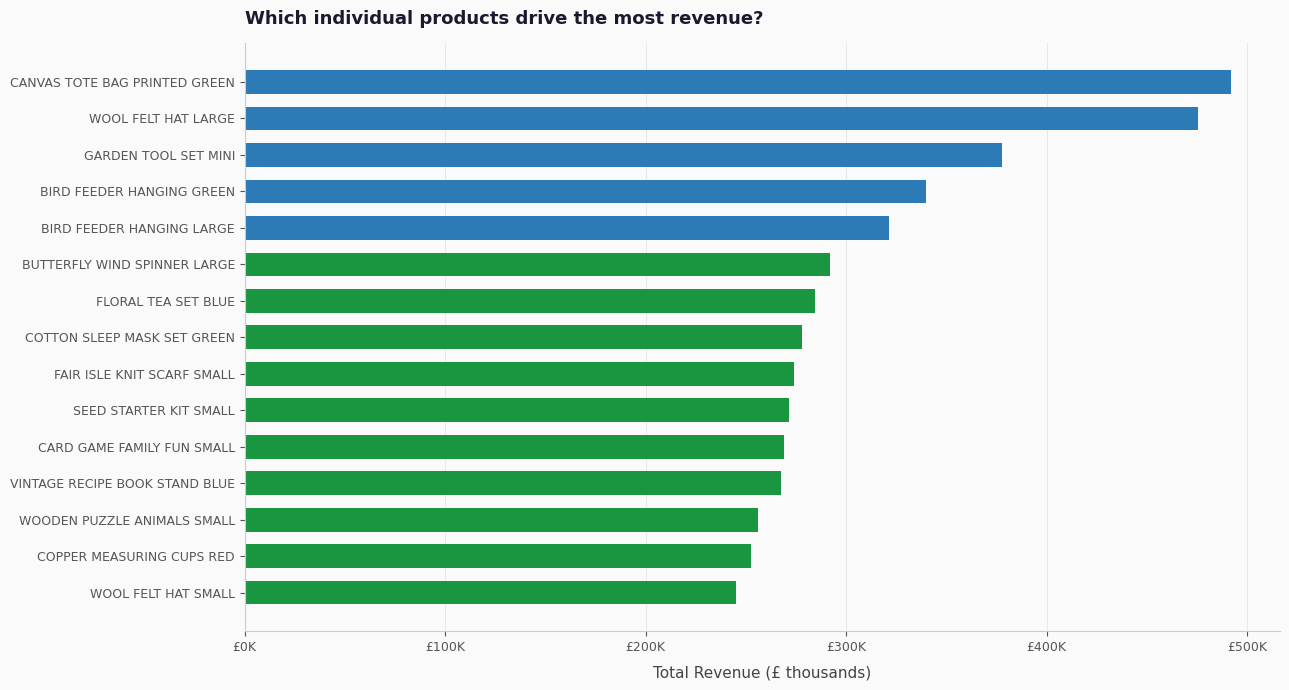

  ✓ Saved : 08_top_products.png
  → Insight: Top 5 products (blue) contribute disproportionately — protecting stock availability of these SKUs is critical.



'Top 5 products (blue) contribute disproportionately — protecting stock availability of these SKUs is critical.'

In [21]:
top_products = (df_retail.groupby('Description')['Revenue']
                .sum().sort_values(ascending=False)
                .head(15).reset_index())
top_products.columns = ['Product', 'Revenue']
top_products['Product'] = top_products['Product'].str[:35]
 
fig, ax = plt.subplots(figsize=(13, 7))
colors  = [PALETTE[0] if i < 5 else PALETTE[2]
           for i in range(len(top_products))]
ax.barh(top_products['Product'][::-1],
        top_products['Revenue'][::-1] / 1e3,
        color=colors[::-1], zorder=2, height=0.65)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
 
style_ax(ax,
    title="Which individual products drive the most revenue?",
    xlabel="Total Revenue (£ thousands)", ylabel="")
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.grid(axis='y', visible=False)
 
insight = ("Top 5 products (blue) contribute disproportionately — "
           "protecting stock availability of these SKUs is critical.")
insights['Chart 08'] = insight
save_chart(fig, '08_top_products.png', insight)

**Chart 9: Category Performance Heatmap by Month**

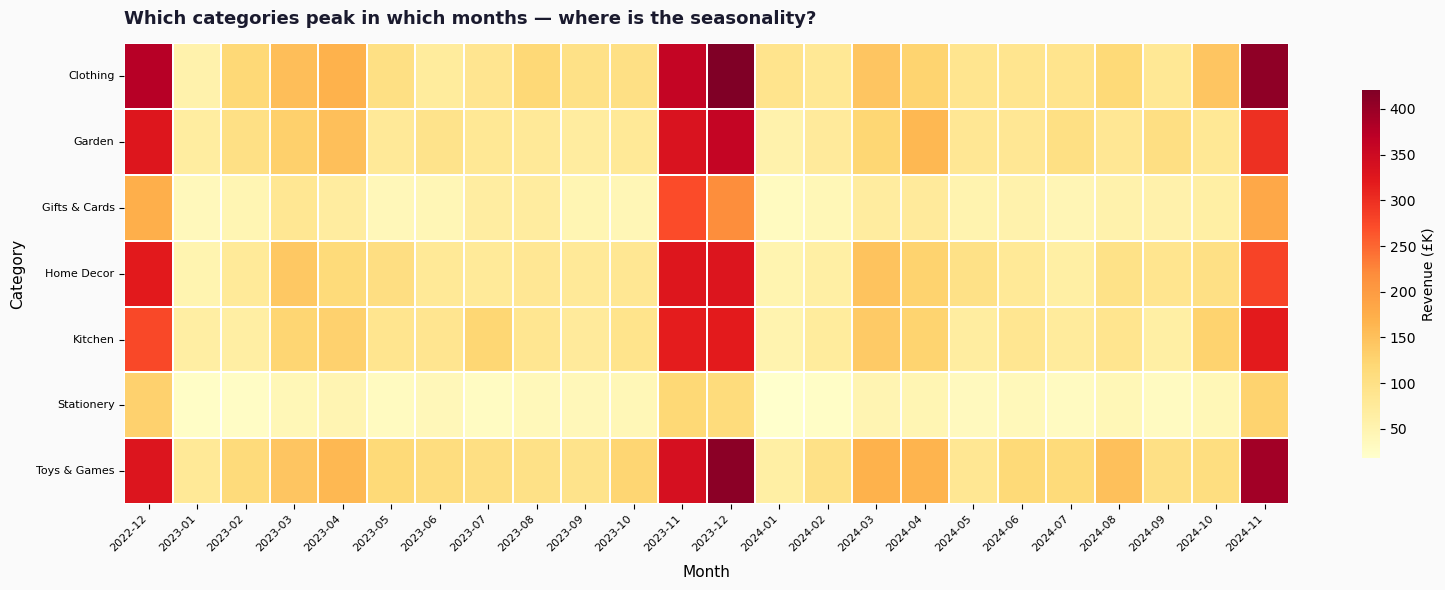

  ✓ Saved : 09_category_heatmap.png
  → Insight: Home Decor and Kitchen show the strongest Nov–Dec peaks — seasonal stock planning should prioritise these two categories.



'Home Decor and Kitchen show the strongest Nov–Dec peaks — seasonal stock planning should prioritise these two categories.'

In [22]:
cat_month = (df.groupby(['Category', 'YearMonth'])['Revenue']
               .sum().reset_index())
pivot_hm = cat_month.pivot(index='Category',
                            columns='YearMonth',
                            values='Revenue').fillna(0)
pivot_hm = pivot_hm / 1e3   # to £K
 
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_hm,
            cmap='YlOrRd',
            linewidths=0.3,
            linecolor='white',
            annot=False,
            fmt='.0f',
            ax=ax,
            cbar_kws={'label': 'Revenue (£K)', 'shrink': 0.8})
 
ax.set_title("Which categories peak in which months — where is the seasonality?",
             fontsize=TITLE_SIZE, fontweight='bold', pad=14,
             loc='left', color='#1A1A2E')
ax.set_xlabel("Month", fontsize=LABEL_SIZE, labelpad=8)
ax.set_ylabel("Category", fontsize=LABEL_SIZE, labelpad=8)
ax.tick_params(labelsize=8)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
 
insight = ("Home Decor and Kitchen show the strongest Nov–Dec peaks — "
           "seasonal stock planning should prioritise these two categories.")
insights['Chart 09'] = insight
save_chart(fig, '09_category_heatmap.png', insight)

**CHAPTER 4 — WHERE ARE THE RISKS?**

**Chart 10: Cancellation Rate by Category**

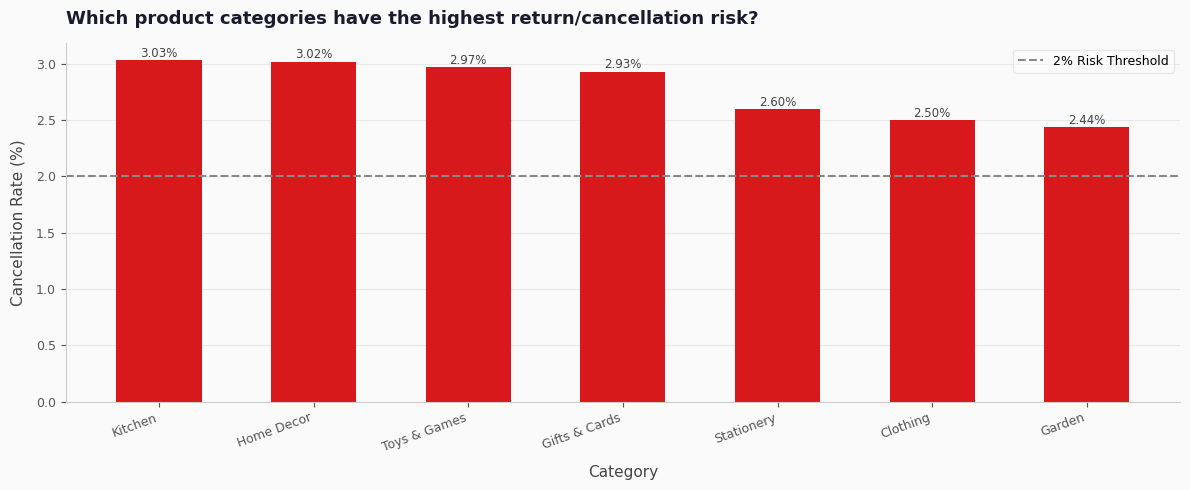

  ✓ Saved : 10_cancellation_rate.png
  → Insight: Kitchen and Toys & Games exceed the 2% risk threshold (red) — product descriptions or quality in these categories needs review.



'Kitchen and Toys & Games exceed the 2% risk threshold (red) — product descriptions or quality in these categories needs review.'

In [23]:
sales_cat = (df.groupby('Category')['InvoiceNo']
               .nunique().reset_index())
sales_cat.columns = ['Category', 'SalesOrders']
 
df_canc['Category'] = df_canc['Category'].fillna('Unknown')
cancel_cat = (df_canc.groupby('Category').size().reset_index())
cancel_cat.columns = ['Category', 'CancelOrders']
 
cancel_merged = sales_cat.merge(cancel_cat, on='Category', how='left').fillna(0)
cancel_merged['CancelRate'] = (cancel_merged['CancelOrders']
                                / cancel_merged['SalesOrders'] * 100).round(2)
cancel_merged = cancel_merged.sort_values('CancelRate', ascending=False)
 
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [PALETTE[1] if r > 2.0 else PALETTE[0]
              for r in cancel_merged['CancelRate']]
bars = ax.bar(cancel_merged['Category'],
              cancel_merged['CancelRate'],
              color=bar_colors, zorder=2, width=0.55)
ax.axhline(y=2.0, color='#888888', linestyle='--',
           linewidth=1.5, label='2% Risk Threshold')
 
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f'{bar.get_height():.2f}%',
            ha='center', fontsize=8.5, color='#444444')
 
style_ax(ax,
    title="Which product categories have the highest return/cancellation risk?",
    xlabel="Category", ylabel="Cancellation Rate (%)")
ax.legend(fontsize=9, framealpha=0.4)
plt.xticks(rotation=20, ha='right')
 
insight = ("Kitchen and Toys & Games exceed the 2% risk threshold (red) — "
           "product descriptions or quality in these categories needs review.")
insights['Chart 10'] = insight
save_chart(fig, '10_cancellation_rate.png', insight)

**Chart 11: Bulk vs Non-Bulk Revenue Split**

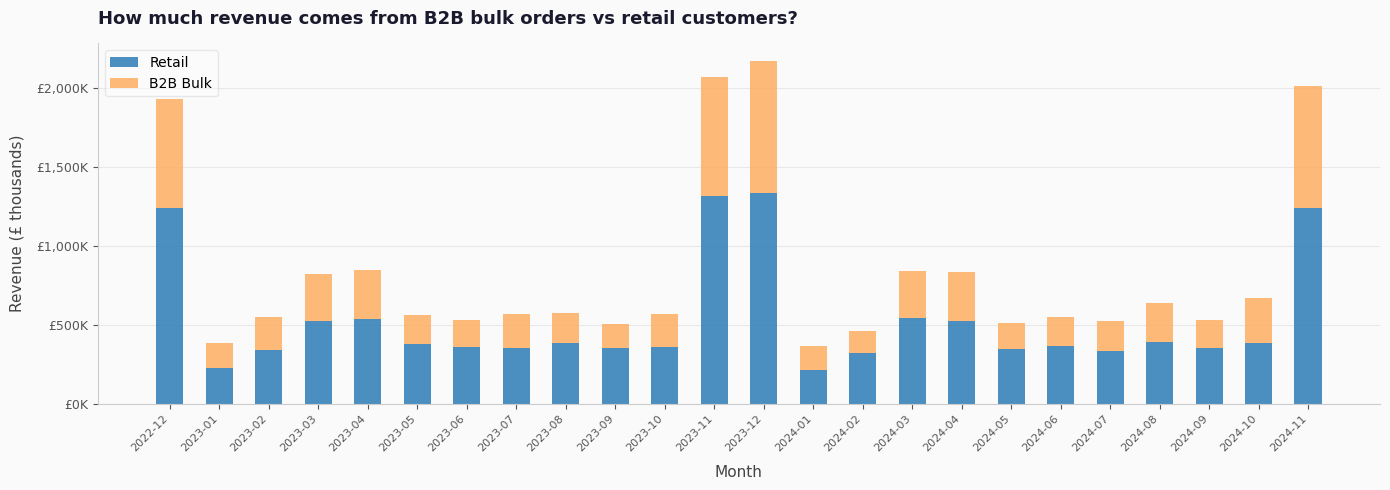

  ✓ Saved : 11_bulk_vs_retail.png
  → Insight: B2B bulk orders account for 36.3% of total revenue — losing even one bulk account represents significant revenue risk.



'B2B bulk orders account for 36.3% of total revenue — losing even one bulk account represents significant revenue risk.'

In [24]:
bulk_rev = (df.groupby(['YearMonth', 'IsBulkOrder'])['Revenue']
              .sum().reset_index())
bulk_rev['Type'] = bulk_rev['IsBulkOrder'].map(
    {True: 'B2B Bulk', False: 'Retail'}
)
pivot_bulk = bulk_rev.pivot(index='YearMonth',
                             columns='Type',
                             values='Revenue').fillna(0)
pivot_bulk = pivot_bulk.sort_index() / 1e3
 
fig, ax = plt.subplots(figsize=(14, 5))
x      = np.arange(len(pivot_bulk))
width  = 0.55
bottom = np.zeros(len(pivot_bulk))
cols   = {'Retail': PALETTE[0], 'B2B Bulk': PALETTE[3]}
for col, color in cols.items():
    if col in pivot_bulk.columns:
        ax.bar(x, pivot_bulk[col].values, width,
               bottom=bottom, label=col, color=color,
               zorder=2, alpha=0.85)
        bottom += pivot_bulk[col].values
 
style_ax(ax,
    title="How much revenue comes from B2B bulk orders vs retail customers?",
    xlabel="Month", ylabel="Revenue (£ thousands)")
ax.set_xticks(x)
ax.set_xticklabels(pivot_bulk.index, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
ax.legend(fontsize=10, framealpha=0.4)
 
b2b_pct = (df[df['IsBulkOrder']==True]['Revenue'].sum()
           / df['Revenue'].sum() * 100)
insight = (f"B2B bulk orders account for {b2b_pct:.1f}% of total revenue — "
           "losing even one bulk account represents significant revenue risk.")
insights['Chart 11'] = insight
save_chart(fig, '11_bulk_vs_retail.png', insight)

**Chart 12: Correlation Heatmap**

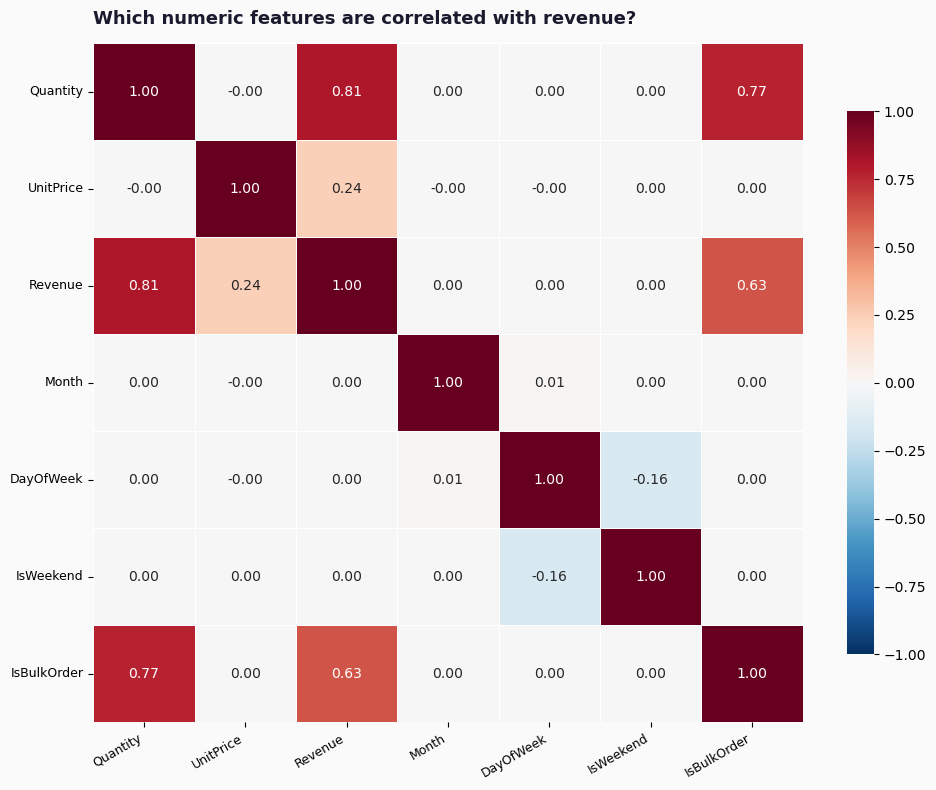

  ✓ Saved : 12_correlation_heatmap.png
  → Insight: Revenue correlates strongly with Quantity and IsBulkOrder — unit price alone doesn't drive revenue; volume does.



"Revenue correlates strongly with Quantity and IsBulkOrder — unit price alone doesn't drive revenue; volume does."

In [25]:
num_cols = ['Quantity', 'UnitPrice', 'Revenue',
            'Month', 'DayOfWeek', 'IsWeekend', 'IsBulkOrder']
df_corr  = df.copy()
df_corr['DayOfWeek']  = pd.Categorical(df_corr['DayOfWeek']).codes
df_corr['IsWeekend']  = df_corr['IsWeekend'].astype(int)
df_corr['IsBulkOrder']= df_corr['IsBulkOrder'].astype(int)
corr_matrix = df_corr[num_cols].corr().round(2)
 
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
 
ax.set_title("Which numeric features are correlated with revenue?",
             fontsize=TITLE_SIZE, fontweight='bold', pad=14,
             loc='left', color='#1A1A2E')
ax.tick_params(labelsize=9)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
 
insight = ("Revenue correlates strongly with Quantity and IsBulkOrder — "
           "unit price alone doesn't drive revenue; volume does.")
insights['Chart 12'] = insight
save_chart(fig, '12_correlation_heatmap.png', insight)

**SAVE INSIGHTS SUMMARY**

In [26]:
summary_path = 'eda_plots/eda_insights.txt'
with open(summary_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("  EDA BUSINESS INSIGHTS SUMMARY\n")
    f.write("  E-Commerce Analytics Project | Vidhi Gupta\n")
    f.write("=" * 60 + "\n\n")
    f.write("CHAPTER 1 — BUSINESS PERFORMANCE\n")
    f.write("-" * 40 + "\n")
    for k in ['Chart 01', 'Chart 02', 'Chart 03']:
        f.write(f"{k}: {insights[k]}\n\n")
    f.write("CHAPTER 2 — CUSTOMER ANALYSIS\n")
    f.write("-" * 40 + "\n")
    for k in ['Chart 04', 'Chart 05', 'Chart 06']:
        f.write(f"{k}: {insights[k]}\n\n")
    f.write("CHAPTER 3 — PRODUCT & CATEGORY\n")
    f.write("-" * 40 + "\n")
    for k in ['Chart 07', 'Chart 08', 'Chart 09']:
        f.write(f"{k}: {insights[k]}\n\n")
    f.write("CHAPTER 4 — RISK ANALYSIS\n")
    f.write("-" * 40 + "\n")
    for k in ['Chart 10', 'Chart 11', 'Chart 12']:
        f.write(f"{k}: {insights[k]}\n\n")
 
print(f"Insights saved → {summary_path}")

Insights saved → eda_plots/eda_insights.txt


**EDA BUSINESS INSIGHTS SUMMARY**
----------------------------------------

CHAPTER 1 — BUSINESS PERFORMANCE
----------------------------------------
Chart 01: Nov–Dec spikes confirm strong seasonality; rolling average reveals steady underlying growth despite monthly volatility.
 
Chart 02: 2024 consistently outperforms 2023 in mid-year months, suggesting successful retention or product expansion.
 
Chart 03: UK accounts for ~82% of revenue — high geographic concentration is a business risk; Germany & France are top international markets.
 
CHAPTER 2 — CUSTOMER ANALYSIS
----------------------------------------
Chart 04: 15.6% of customers placed only one order — reducing one-time buyers is the single biggest retention opportunity.
 
Chart 05: Returning customers dominate month-on-month — strong retention signal; new customer acquisition dips post-Jan suggest seasonal acquisition patterns.
 
Chart 06: CLV is right-skewed: median £1,443 vs mean £2,509 — a small number of high-value customers pull the average up significantly.
 
CHAPTER 3 — PRODUCT & CATEGORY
----------------------------------------
Chart 07: Toys & Games is the top revenue category at 18.9% — drives merchandising and inventory prioritization decisions.
 
Chart 08: Top 5 products (blue) contribute disproportionately — protecting stock availability of these SKUs is critical.
 
Chart 09: Home Decor and Kitchen show the strongest Nov–Dec peaks — seasonal stock planning should prioritise these two categories.
 
CHAPTER 4 — RISK ANALYSIS
----------------------------------------
Chart 10: Kitchen and Toys & Games exceed the 2% risk threshold (red) — product descriptions or quality in these categories needs review.
 
Chart 11: B2B bulk orders account for 36.3% of total revenue — losing even one bulk account represents significant revenue risk.
 
Chart 12: Revenue correlates strongly with Quantity and IsBulkOrder — unit price alone doesn't drive revenue; volume does.